### Generate data with known properties and examine fit and residuals.

This notebook outlines the way to fit a polynomial to a set of data
using the numpy linear algebra module.

Instructions:
 - Examine code cells and insert plausible values for variables.
 - Generate the data using coefficients you select. Pick some higher order polynomial, at least cubic.
 - Demonstrate that a linear fit is a poor representation of the data.
 - Copy codes to fit a higher order polynomial.

A good fit would have the standard deviation of the residuals close to the value
of the mean errors you chose.

This notebook makes use of numpy arithmetic procedures for handling arrays.

If you missed class on November 12, you may have to look up stuff about numpy and least-squares fitting.

Turn your completed notebook in via Carmen.

In [1]:
# import stuff
import numpy as np
import matplotlib.pyplot as plt

#### Set up some X values.

In [2]:
# ------ Change these values any way you want.
# Random X values over some interval
npoints = 20
xmin = -20
xmax = 33
X = np.random.uniform(xmin, xmax, npoints)

#### Specify some polynomial in Y with a standard deviation representing errors in Y.

In [3]:
# ------- Change these values any way you want.
sigma = 200.0                         # Noise
G = [-112.0, 42.5, -0.92, 0.1]        # Polynomial coefficients of generating function.

Y = G[0] + G[1] * X + G[2] * X**2 + G[3] * X**3 \
  + np.random.normal(0.0, sigma, npoints)

#### Plot the data

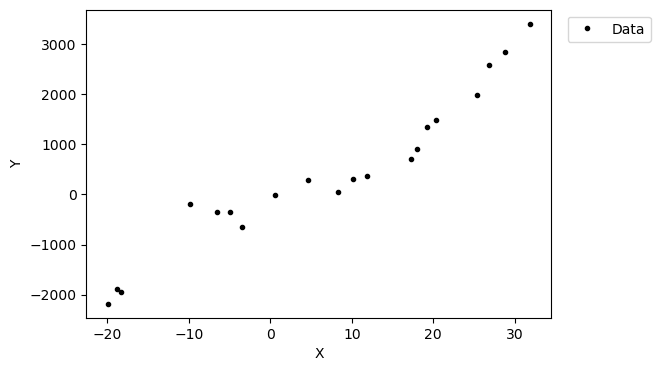

In [4]:
# Scribe the plot 
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(X, Y, '.k', label='Data')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(bbox_to_anchor=(1.02, 1.00), loc="upper left")
plt.show()

#### Do a fit and examine the result

In [5]:
# BASIS VECTORS
x0 = np.ones(len(X))
x1 = X


# Set up the matrix and solve
M = np.vstack([x1, x0]).T  # T denotes matrix transpose
C = np.linalg.lstsq(M, Y, rcond=None)[0]   # Return 1st element

# Show what this is
print('Type of returned object   : ', type(C))
print('Length of returned object : ', len(C))
print(C)

Type of returned object   :  <class 'numpy.ndarray'>
Length of returned object :  2
[  89.17360982 -197.11208222]


#### Generate an array for a model in X and Y

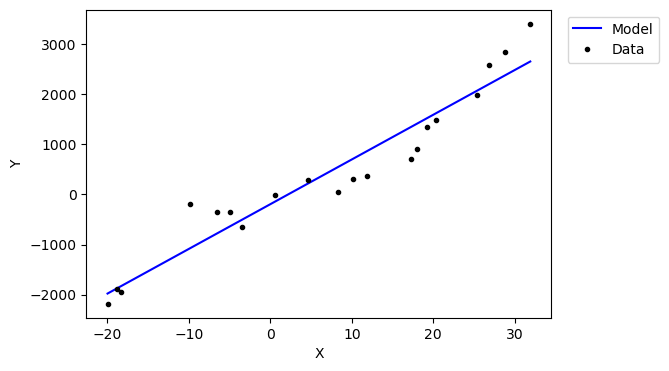

In [6]:
# Range of X
xmin   = np.amin(X)
xmax   = np.amax(X)
nmodel = 128
xmodel = np.linspace(xmin, xmax, nmodel, endpoint=True)
# Y from coefficients
ymodel = C[0] * xmodel + C[1]   # Linear case

# Plot
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(xmodel, ymodel, 'blue', label='Model')
ax.plot(X, Y, '.k', label='Data')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(bbox_to_anchor=(1.02, 1.00), loc="upper left")
plt.show()

#### Compute and plot residuals

We use the model coefficients.

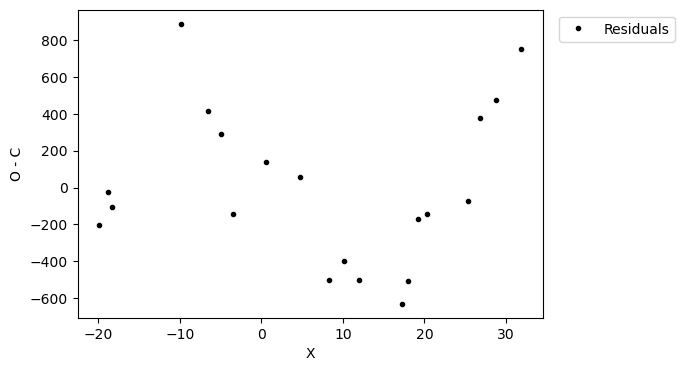

In [7]:
# Residuals are Y - calculated
ycalc = C[0] * X + C[1]          
yresid = Y - ycalc

# Plot
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(X, yresid, '.k', label='Residuals')
ax.set_xlabel('X')
ax.set_ylabel('O - C')
ax.legend(bbox_to_anchor=(1.02, 1.00), loc="upper left")
plt.show()

__Remark:__ If the model is a good one, we expect the residuals to look like they
are distributed randomly around zero, as in
$$
{\rm residual} \sim N(0, \sigma)
$$

#### Compute the standard deviation

Compare it to the generating value.

In [8]:
# There's a numpy function for that.
scatter = np.std(yresid)
print('Sigma from generating function: %.2f' % sigma)
print('Residual r.m.s.               : %.2f' % scatter)

Sigma from generating function: 200.00
Residual r.m.s.               : 415.33


__Copy codes below here to generate a higher-order fit.__

In [13]:
x0 = np.ones(len(X))
x1 = X
x2 = X**2
x3 = X**3

M3 = np.vstack([x3, x2, x1, x0]).T 
C3 = np.linalg.lstsq(M3, Y, rcond=None)[0]

print("Cubic Fit Coefficients (Highest power first)")
print(C3)

Cubic Fit Coefficients (Highest power first)
[  0.10223087  -0.96379498  42.74654461 -78.25629736]


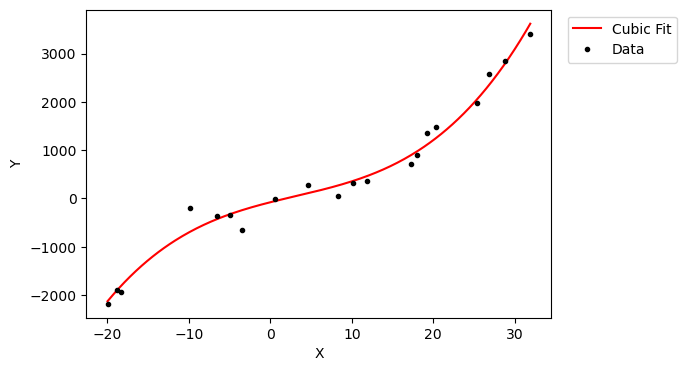

In [10]:
xmodel = np.linspace(np.amin(X), np.amax(X), 300)
ymodel3 = C3[0]*xmodel**3 + C3[1]*xmodel**2 + C3[2]*xmodel + C3[3]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(xmodel, ymodel3, 'red', label='Cubic Fit')
ax.plot(X, Y, '.k', label='Data')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

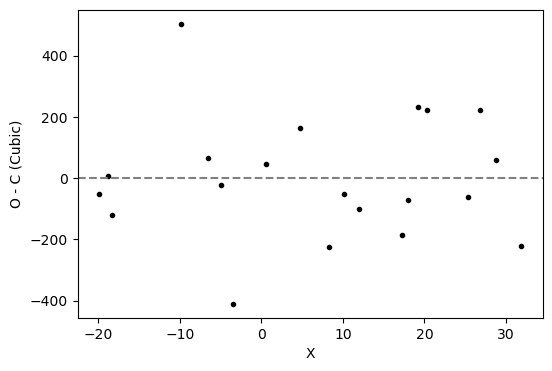

In [11]:
ycalc3 = C3[0]*X**3 + C3[1]*X**2 + C3[2]*X + C3[3]
resid3 = Y - ycalc3

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(X, resid3, '.k')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('X')
ax.set_ylabel('O - C (Cubic)')
plt.show()



In [12]:
scatter3 = np.std(resid3)
print("Sigma from generating function: %.2f" % sigma)
print("Residual RMS (cubic fit):       %.2f" % scatter3)

Sigma from generating function: 200.00
Residual RMS (cubic fit):       198.11
